In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# 자전거 데이터 캐글
https://www.kaggle.com/c/bike-sharing-demand/overview

In [2]:
# 데이터 불러오기
bike_df = pd.read_csv('data/bike_train.csv')#TODO:YOUR_CODE_HERE
bike_df.head(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [3]:
bike_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1.2 MB


In [ ]:
# 문자열을 datetime 타입으로 변경.
bike_df['datetime'] = bike_df.datetime.apply(pd.to_datetime)

# datetime 타입에서 년, 월, 일, 시간 추출
# 년 추출 #TODO:YOUR_CODE_HERE
# 월 추출 #TODO:YOUR_CODE_HERE
# 일 추출 #TODO:YOUR_CODE_HERE
# 시간 추출 #TODO:YOUR_CODE_HERE
bike_df.head(3)

In [5]:
bike_df['month'] = bike_df['datetime'].dt.month
bike_df['hour'] = bike_df['datetime'].dt.hour
bike_df['dayofweek'] = bike_df['datetime'].dt.dayofweek
bike_df.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,dayofweek
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,0,5
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,5
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,2,5


<Axes: >

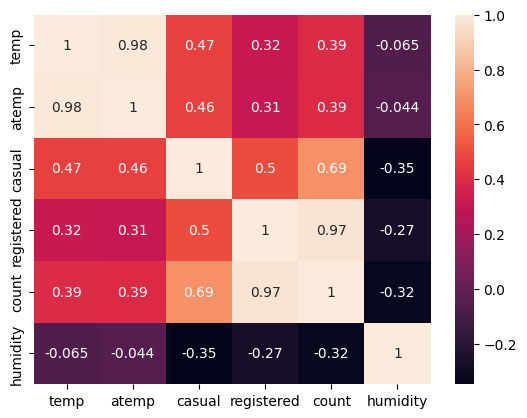

In [6]:
corr = bike_df[['temp','atemp', 'casual','registered',  'count','humidity' ]].corr()
sns.heatmap(corr, annot=True)

In [ ]:
drop_columns = ['datetime','casual','registered']
# 필요없는 컬럼 삭제하기

In [ ]:
# EDA를 위한 시각화하기
# 조건에 따른 대여량 시각화

In [ ]:
# TODO: 막대 그래프(년, 월, 시즌, 날씨, 일, 시간, 휴일, 근무일)

In [ ]:
# 의미 도출 

In [7]:
bike_df.head(1)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,dayofweek
0,2011-01-01,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,0,5


In [8]:
# 변수선택 - 종속변수, 독립변수를 결정
X = bike_df[['season','holiday','workingday', 'weather','atemp', 'humidity', 'windspeed', 'month', 'hour', 'dayofweek']]
y = bike_df['count']

In [9]:
# 훈련세트/테스트세트 분할
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(7620, 10) (3266, 10) (7620,) (3266,)


In [10]:
# 모델 생성 및 훈련, MSE, R2 score

from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [11]:
model.fit(X_train, y_train)

LinearRegression()

In [12]:
pred = model.predict(X_test)

In [14]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score

print(f'RMSE: {root_mean_squared_error(y_test, pred):.2f}') 
print(f'MSE: {mean_squared_error(y_test, pred):.2f}') # 평균 제곱 오차(MSE)
print(f'r2_score: {r2_score(y_test, pred):.2f}') # 결정계수(R2)

RMSE: 147.65
MSE: 21800.15
r2_score: 0.33


In [16]:
X.sample(5)

,season,holiday,workingday,weather,atemp,humidity,windspeed,month,hour,dayofweek
5031,4,0,0,1,18.940,62,0.0000,12,17,5
8403,3,0,1,2,34.850,43,0.0000,7,12,2
8452,3,0,1,2,35.605,38,8.9981,7,13,4
7984,2,0,1,1,29.545,78,0.0000,6,1,2
1471,2,0,1,1,16.665,76,12.9980,4,4,3


In [ ]:
# 수치형변수 스케일링 

In [17]:
# 범주형변수 원핫인코딩 
cf_columns = ['season','weather','month', 'hour', 'dayofweek' , 'holiday', 'workingday' ]
X_encoded = pd.get_dummies(X, columns=cf_columns)

In [18]:
X_encoded

,atemp,humidity,windspeed,season_1,season_2,season_3,season_4,weather_1,weather_2,weather_3,...,dayofweek_1,dayofweek_2,dayofweek_3,dayofweek_4,dayofweek_5,dayofweek_6,holiday_0,holiday_1,workingday_0,workingday_1
0,14.395,81,0.0000,True,False,False,False,True,False,False,...,False,False,False,False,True,False,True,False,True,False
1,13.635,80,0.0000,True,False,False,False,True,False,False,...,False,False,False,False,True,False,True,False,True,False
2,13.635,80,0.0000,True,False,False,False,True,False,False,...,False,False,False,False,True,False,True,False,True,False
3,14.395,75,0.0000,True,False,False,False,True,False,False,...,False,False,False,False,True,False,True,False,True,False
4,14.395,75,0.0000,True,False,False,False,True,False,False,...,False,False,False,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,19.695,50,26.0027,False,False,False,True,True,False,False,...,False,True,False,False,False,False,True,False,False,True
10882,17.425,57,15.0013,False,False,False,True,True,False,False,...,False,True,False,False,False,False,True,False,False,True
10883,15.910,61,15.0013,False,False,False,True,True,False,False,...,False,True,False,False,False,False,True,False,False,True
10884,17.425,61,6.0032,False,False,False,True,True,False,False,...,False,True,False,False,False,False,True,False,False,True


In [19]:
X_encoded_train, X_encoded_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state = 42)

In [20]:
from sklearn.linear_model import LinearRegression

model2 = LinearRegression()
model2.fit(X_encoded_train, y_train)
pred2 = model2.predict(X_encoded_test)

In [21]:
print(f'MSE: {mean_squared_error(y_test, pred2):.2f}') # 평균 제곱 오차(MSE)
print(f'r2_score: {r2_score(y_test, pred2):.2f}') # 결정계수(R2)

MSE: 12441.56
r2_score: 0.62


In [ ]:
MSE: 21800.15
r2_score: 0.33

In [23]:
testdf = pd.DataFrame()
testdf['pred'] = pred2
testdf['answer'] = y_test
testdf

,pred,answer
0,279.583008,16.0
1,-23.045898,NaN
2,387.318359,NaN
3,221.175781,13.0
4,163.370117,NaN
...,...,...
3261,85.316406,NaN
3262,195.315430,NaN
3263,233.847656,173.0
3264,478.056641,NaN


In [ ]:
# 최종 훈련 테스트 데이터 만들어서 모델 생성 및 훈련

In [ ]:
# 새로운 데이터 예측 하기 

new_row = {
    "season": 2, "holiday": 0, "workingday": 1, "weather": 1,
    "atemp": 20.5, "humidity": 55, "windspeed": 0.12,
    "year": 2025, "month": 5, "day": 1, "hour": 17, "dayofweek": 3
}

new_df = pd.DataFrame([new_row])


print(f"예상 대여 수: {count_pred:.0f}대")